250709- I am going to retry on making a code for multiple parrellel interface but with better organazation. 

This is an updated form of our earlier plotting function. I have named it totalFresnalcoeffPlot. I will use it to plot the total transmission coefficients for p and s polarized light. our input variables are n_0, n_1, n_2, k_0, k_1, k_2, d, th0, Wavelength. Wavlength and d will be given in integers because for now we only care about their ratio. Wavelenghth stands for $\lambda _0$. I am using the eqautions for the total fresnell coefficints from page 91-93 of the byu book and then reproducing the graph on page 93. Here I defined general eqautions for the fresnell coefficints at any boundry(r_s,t_s,r_p,t_p). I then defined the total fresnell coefficients these variables t_s_nin0_ntn1 = t_s(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) that sends different inputs into the general eqautions defined above. In my naming convention t_s_nin0_ntn1, nin0 means that n0 replaces ni in the general t_s eqaition and ntn1 replaces nt in the  general t_s eqaution. I carried this through for all others. I also changed $k_1$ used in the byu book to be $(n_1+1j*k_1)\frac{2 \pi}{Wavelenght}$. I then took the magnitude to properly display the complex part of our coeficients. 




interactive(children=(FloatSlider(value=1.0, description='n0', max=5.0), FloatSlider(value=1.4, description='n…

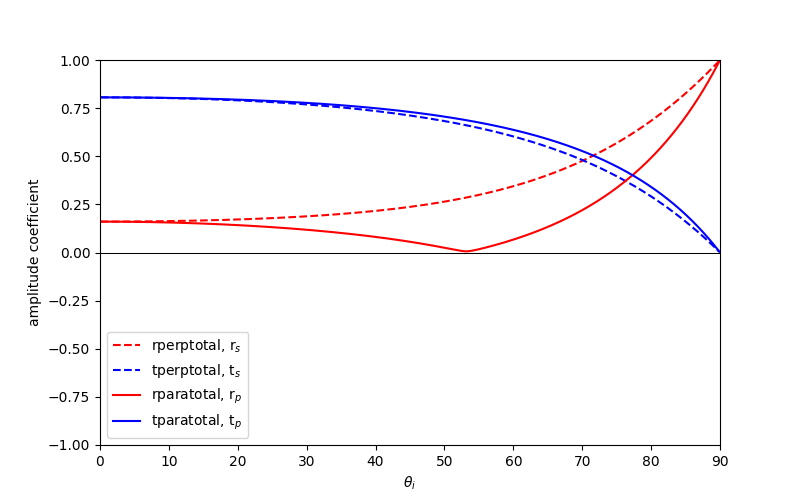

In [2]:
%matplotlib widget

# import time
# start = time.time()
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd    

# 1 plotting function 

def totalFresnalcoeffPlot(func1, func2, func3, func4):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    th0 = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[], 'r--')
    line02, = ax0.plot([],[], 'b--')
    line03, = ax0.plot([],[], 'r-')
    line04, = ax0.plot([],[], 'b-')
    ax0.set_xlim((0,90))
    ax0.set_ylim((-1,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('amplitude coefficient')
    ax0.legend([r'rperptotal, r$_s$', r'tperptotal, t$_s$', r'rparatotal, r$_p$', r'tparatotal, t$_p$'],)
    def plot(n0=1, n1=1.4, n2=1.5, k0=0, k1=0, k2=0, d=1, Wavelength=4):
        output1 = func1(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        output2 = func2(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        output3 = func3(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        output4 = func4(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        line01.set_data(th0, output1)
        line02.set_data(th0, output2)
        line03.set_data(th0, output3)
        line04.set_data(th0, output4)
        plt.draw()
    interact(plot, n0=(0,5,.1), n1=(0,5,.1), n2=(0,5,.1), k0=(0,5,.1), k1=(0,5,.1), k2=(0,5,.1), d=(0,5,.1), Wavelength=(0,5,.1)) # might want to change d and wavelength variables to be more realistic

# 2 Cosine and angle functions 

def cos(th):
    return np.cos(th*np.pi/180) 

def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2)) 

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi 

def sin(th):
    return np.sin(th*np.pi/180) 

# 3 Returns transmitted angle from incident angle
def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))

# 4 General form of fresnel coefficients for s polarized light (perpindicular electric field) 
def r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(((ni+1j*ki)/mui*cos_thi-(nt+1j*kt)/mut*cos_tht)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht)) 

def t_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)  
    return((2*(ni+1j*ki)/mui*cos_thi)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht))

# 5 General form of fresnel coefficients for p polarized light (parrallel electric field)  

def r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((-(nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))

def t_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((2*(ni+1j*ki)/mui*cos_thi)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))  

# 6 total fresnel coefficints s polarized

def t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    t_s_nin0_ntn1 = t_s(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12)
    t_s_nin1_ntn2 = t_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12)
    r_s_nin1_ntn0 = r_s(n1, n0, k1, k0, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    r_s_nin1_ntn2 = r_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12)
    return((t_s_nin0_ntn1*np.exp(1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength)*t_s_nin1_ntn2)/(1-r_s_nin1_ntn0*np.exp(2*1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength)*r_s_nin1_ntn2))


def r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    r_s_nin0_ntn1 = r_s(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    r_s_nin1_ntn2 = r_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    r_s_nin1_ntn0 = r_s(n1, n0, k1, k0, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    r_s_nin1_ntn2 = r_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    t_s_nin0_ntn1 = t_s(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    t_s_nin1_ntn2 = t_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12)
    return(r_s_nin0_ntn1+((np.exp(2*1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength)*t_s_nin0_ntn1*r_s_nin1_ntn2*t_s_nin1_ntn2)/(1-r_s_nin1_ntn0*r_s_nin1_ntn2*np.exp(2*1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength))))  

# 6 total fresnel coefficints p polarized 

def t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    t_p_nin0_ntn1 = t_p(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12)
    t_p_nin1_ntn2 = t_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12)
    r_p_nin1_ntn0 = r_p(n1, n0, k1, k0, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    r_p_nin1_ntn2 = r_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12)
    return((t_p_nin0_ntn1*np.exp(1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength)*t_p_nin1_ntn2)/(1-r_p_nin1_ntn0*np.exp(2*1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength)*r_p_nin1_ntn2))


def r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    r_p_nin0_ntn1 = r_p(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    r_p_nin1_ntn2 = r_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    r_p_nin1_ntn0 = r_p(n1, n0, k1, k0, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    r_p_nin1_ntn2 = r_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    t_p_nin0_ntn1 = t_p(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    t_p_nin1_ntn2 = t_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12)
    return(r_p_nin0_ntn1+((np.exp(2*1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength)*t_p_nin0_ntn1*r_p_nin1_ntn2*t_p_nin1_ntn2)/(1-r_p_nin1_ntn0*r_p_nin1_ntn2*np.exp(2*1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength))))  

def mag_r_p_tot(*args, **kwargs):
    return np.abs(r_p_tot(*args, **kwargs))   

def mag_r_s_tot(*args, **kwargs):
    return np.abs(r_s_tot(*args, **kwargs))

def mag_t_p_tot(*args, **kwargs):
    return np.abs(t_p_tot(*args, **kwargs))

def mag_t_s_tot(*args, **kwargs):
    return np.abs(t_s_tot(*args, **kwargs)) 

# totalFresnalcoeffPlot(mag_r_p_tot, mag_r_s_tot, mag_t_s_tot, mag_t_p_tot) 

totalFresnalcoeffPlot(mag_r_s_tot, mag_t_s_tot, mag_r_p_tot, mag_t_p_tot)

# end = time.time()

# print(f"Runtime: {end - start:.6f} seconds")
